# <center> Machine Learning II (DSCI 364)
## <center> Becamex Business School
##### <center> Kang Seung Won (kwon.kang@eiu.edu.vn)
---

## NPNG in DSCI 364

- #### No Pain No Gain (NPNG) $\rightarrow$ `"Pain Makes Gain"`
- #### No Practice No Gain (NPNG) $\rightarrow$ `"Practice Makes Perfect"`

---

# Gradient Descent
- Big Dipper (Bắc Đẩu) (https://www.space.com/27758-big-dipper.html)

- **Gradient:** 
    - Change in the value of a quantity.
    - The degree of steepness of a graph at any point, simplpy, **SLOPE at any point.**
- **Descent:** 
    - An action of moving downward, dropping, or falling
    - Antonym: ascent $\rightarrow$ rise, climb

![Gradient Descent](gd.png)

by Gemini


### Cost Function for Regression

- **Linear Regression:**

    - $\hat{\beta} = (X^{'}X)^{-1}X^{'}y \Rightarrow$ Cost Function (Mean Squared Error (MSE)): $L = \frac{1}{n}\sum(y_i - x_i\hat{\beta_i})^2$ 

    - **Gradient** is **Derivative** of the Cost function w.r.t. $\hat{\beta_i} \text{ or } \hat{y}_i$ 

$$
\begin{align*}
    L &= \frac{1}{n}\sum(y_i - \hat{y}_i)^2 = \frac{1}{n}\sum(y_i-\hat{\beta_i} x_i)^2\\
    \frac{\partial L}{\partial \beta_i} &= -\frac{2}{n}\sum x_i(y_i - \hat{\beta_i} x_i)\\
    \frac{\partial L}{\partial \hat{y}_i} &= - \frac{2}{2n} \sum_{i=1}^{n} x_i(y_i - \hat{y}_i)=- \frac{1}{n} \sum_{i=1}^{n} x_i(y_i - \hat{y}_i)
\end{align*}
$$


### Gradient Descent for Optimization

To **minimize** the Cost(Loss) function, we **update** the model parameters using **gradient descent**.


#### Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
sns.set_style("whitegrid")
mpl.rcParams['figure.figsize'] = (12, 6)

import warnings
warnings.filterwarnings("ignore")

#### Example
- Cost Function: $ C(v) = v^2$
- Then, Gradient or Derivative: $ \frac{\partial C(v)}{\partial v} = 2v$



In [2]:
cost = lambda x: x**2
gradient = lambda x: 2*x


In [7]:
x = np.linspace(-11, 11, 100)

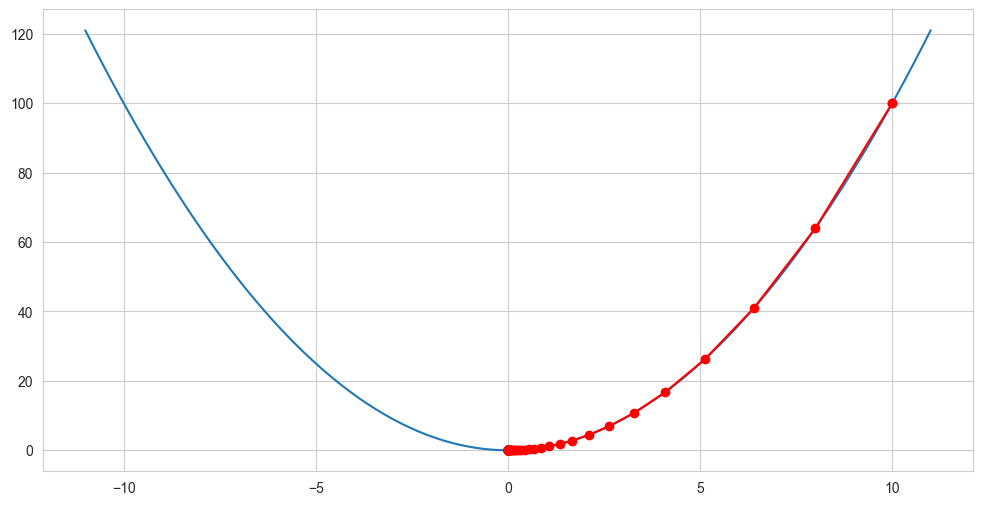

In [ ]:
plt.plot(x, cost(x));
plt.scatter(10, cost(10), color='r');


### Update Rules

- Let $\beta_i = w_i$ (weights) and $b$ (bias) following Machine Learning customs.
- Iteratively update weights and bias to minimize the loss:

$$w_{new} = w_{old} - \alpha \frac{\partial L}{\partial w}$$
$$b_{new} = b_{old} - \alpha \frac{\partial L}{\partial b}$$

   - $\alpha$ is the **learning rate** (step size)
   - $\frac{\partial L}{\partial w}$ is the **gradient** of the cost with respect to weights
   - $\frac{\partial L}{\partial b}$ is the **gradient** of the cost with respect to bias


In [29]:
learning_rate = 0.1
v = 10.0

track = [v]

for i in range(100):
    v -= learning_rate * gradient(v)
    track.append(v)
    
    # Early Stop
    if np.abs(gradient(v)) < 1e-5:
        print(f'Converge to tolerance level at {i}')
        break


track = np.array(track)    
print(track)

Converge to tolerance level at 65
[1.00000000e+01 8.00000000e+00 6.40000000e+00 5.12000000e+00
 4.09600000e+00 3.27680000e+00 2.62144000e+00 2.09715200e+00
 1.67772160e+00 1.34217728e+00 1.07374182e+00 8.58993459e-01
 6.87194767e-01 5.49755814e-01 4.39804651e-01 3.51843721e-01
 2.81474977e-01 2.25179981e-01 1.80143985e-01 1.44115188e-01
 1.15292150e-01 9.22337204e-02 7.37869763e-02 5.90295810e-02
 4.72236648e-02 3.77789319e-02 3.02231455e-02 2.41785164e-02
 1.93428131e-02 1.54742505e-02 1.23794004e-02 9.90352031e-03
 7.92281625e-03 6.33825300e-03 5.07060240e-03 4.05648192e-03
 3.24518554e-03 2.59614843e-03 2.07691874e-03 1.66153499e-03
 1.32922800e-03 1.06338240e-03 8.50705917e-04 6.80564734e-04
 5.44451787e-04 4.35561430e-04 3.48449144e-04 2.78759315e-04
 2.23007452e-04 1.78405962e-04 1.42724769e-04 1.14179815e-04
 9.13438523e-05 7.30750819e-05 5.84600655e-05 4.67680524e-05
 3.74144419e-05 2.99315535e-05 2.39452428e-05 1.91561943e-05
 1.53249554e-05 1.22599643e-05 9.80797146e-06 7.846

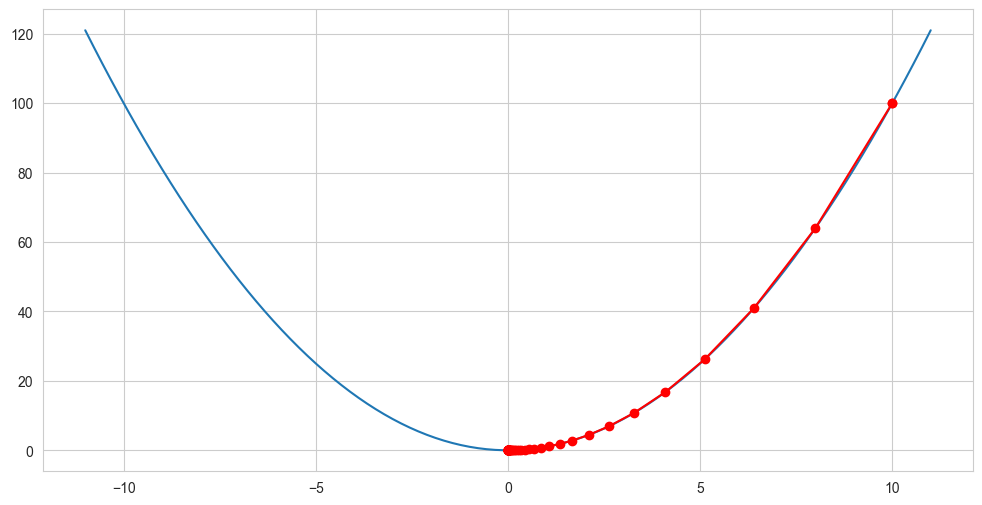

In [30]:
plt.plot(x, cost(x));
plt.scatter(10, cost(10), color='r');
plt.plot(track, cost(track), 'ro-');

### Exercise

In [31]:
from sklearn.datasets import make_regression

In [48]:
X, y = make_regression(n_samples=500, n_features=1, noise=30, random_state=123)

In [33]:
X.shape, y.shape

((500, 1), (500,))

<Axes: >

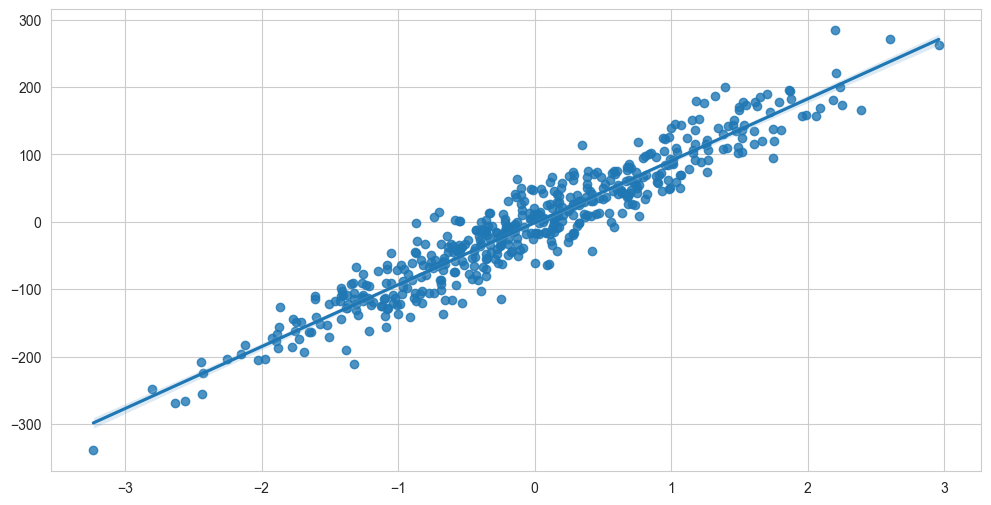

In [37]:
# plt.scatter(X, y);
sns.regplot(x=X, y=y)

### Estimate $w$ (weights) and $b$ (bias) by Gradient Descent

In [70]:
X[:, 0].shape

(500,)

In [71]:
learning_rate = 0.01
def gd(x, y, n_iter, tol=1e-5):
    w = 0.0
    b = 0.0
    N = len(x)
    
    for i in range(n_iter):
        error = y - (w*x + b)
        dw = -(1/N) * np.sum(error*x)
        db = -(1/N) * np.sum(error)

        w -= learning_rate * dw
        b -= learning_rate * db
        
        # Early Stopping
        if np.abs(dw) < tol and np.abs(db) < tol:
            print(i)
            break
    
    return b, w

In [72]:
print(gd(X[:, 0], y, 1000))

# print(gd(X.flatten(), y, 1000))

(np.float64(-1.3196417452748974), np.float64(91.91831600563465))


In [57]:
import pingouin as pg
pg.linear_regression(X, y)

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,-1.318176,1.324044,-0.995568,3.199434e-01,0.90702,0.906834,-3.919577,1.283224
1,x1,91.922248,1.318838,69.699398,5.045368e-259,0.90702,0.906834,89.331075,94.513421


In [77]:
xx = np.c_[np.ones((X.shape[0], 1)), X]
beta = np.linalg.inv(xx.T@xx)@xx.T@y

In [78]:
beta

array([-1.31817611, 91.92224789])